  0%|          | 0/23 [00:00<?, ?it/s]

XJTU_2C_battery-7.pkl
[0, 1]
2.0 1.938


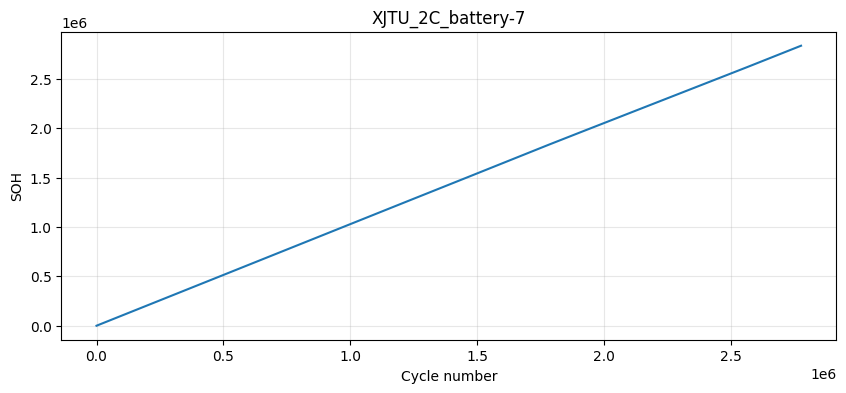

  4%|▍         | 1/23 [00:02<01:01,  2.80s/it]

XJTU_2C_battery-2.pkl
[0, 1]
2.0 1.861


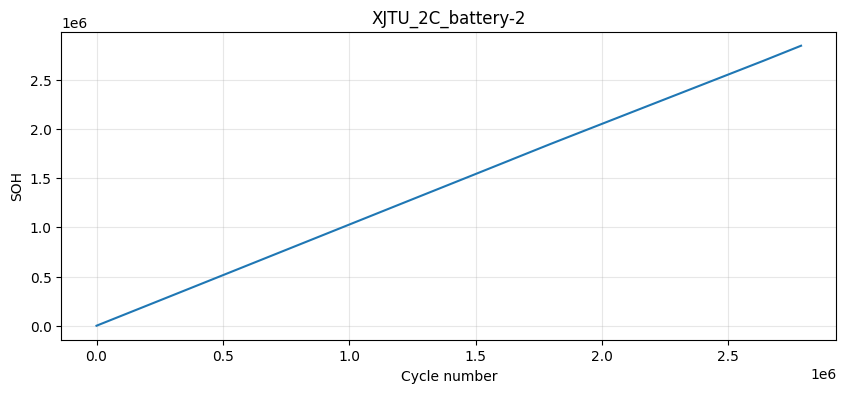

  9%|▊         | 2/23 [00:05<01:00,  2.87s/it]

XJTU_3C_battery-3.pkl
[0, 1]
2.0 1.878


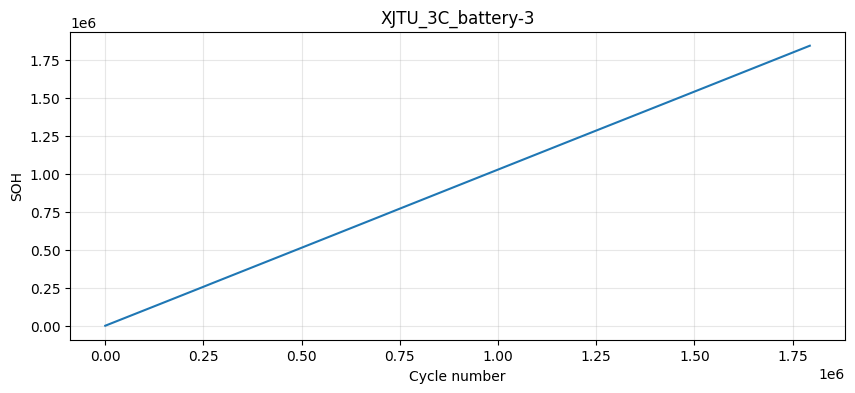

 13%|█▎        | 3/23 [00:07<00:49,  2.48s/it]

XJTU_3C_battery-6.pkl
[0, 1]
2.0 1.861


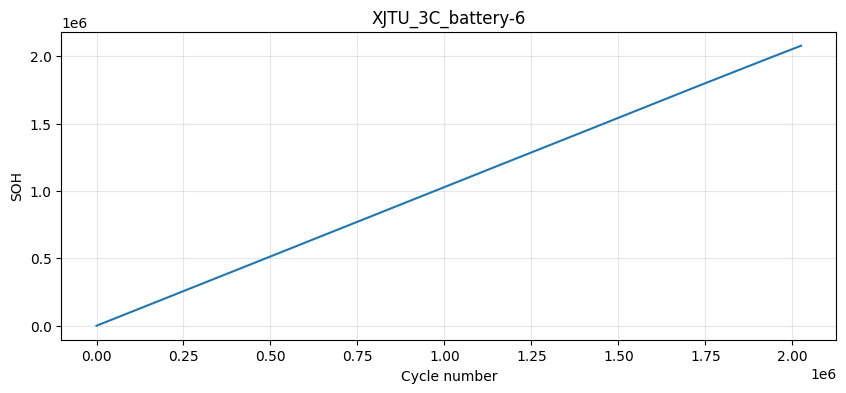

 17%|█▋        | 4/23 [00:09<00:45,  2.39s/it]

XJTU_3C_battery-9.pkl
[0, 1]
2.0 1.802


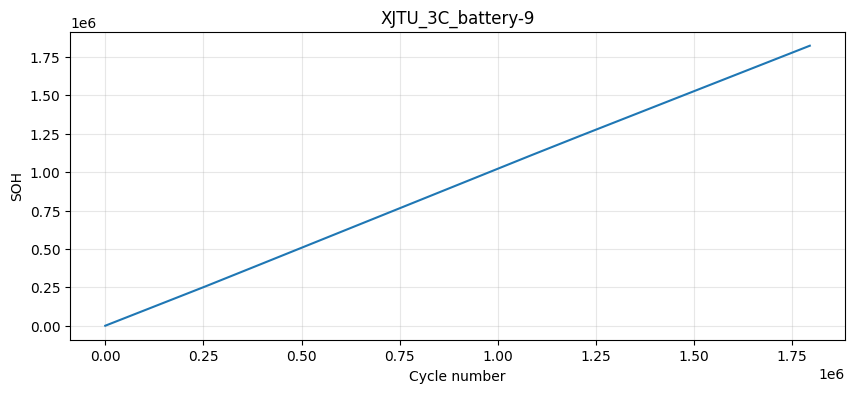

 22%|██▏       | 5/23 [00:11<00:40,  2.22s/it]

XJTU_3C_battery-14.pkl
[0, 1]
2.0 1.794


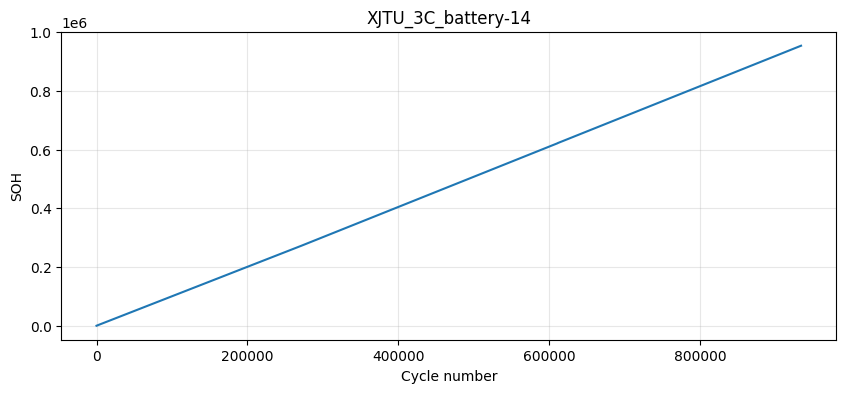

 26%|██▌       | 6/23 [00:12<00:31,  1.83s/it]

XJTU_2C_battery-4.pkl
[0, 1]
2.0 1.858


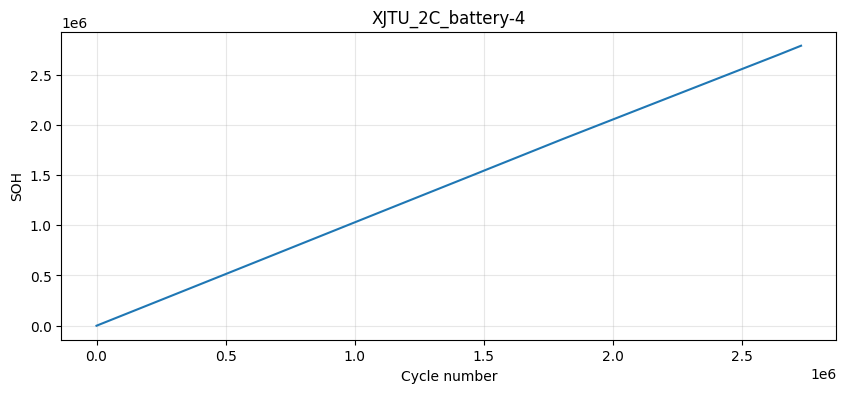

 30%|███       | 7/23 [00:15<00:34,  2.14s/it]

XJTU_3C_battery-7.pkl
[0, 1]
2.0 1.877


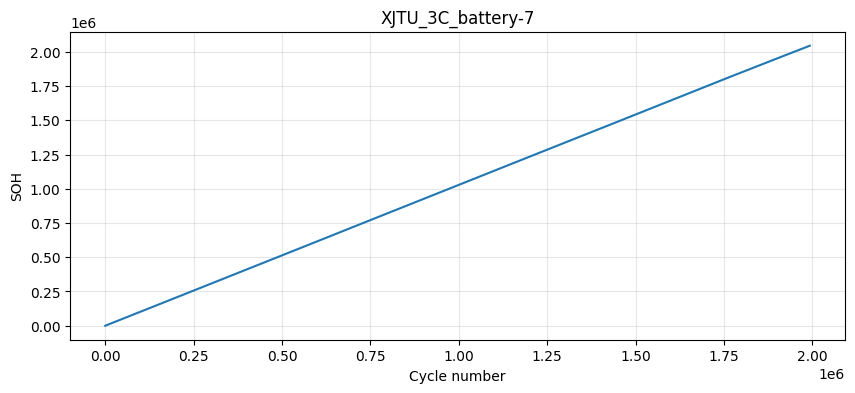

 35%|███▍      | 8/23 [00:17<00:32,  2.15s/it]

XJTU_2C_battery-1.pkl
[0, 1]
2.0 1.863


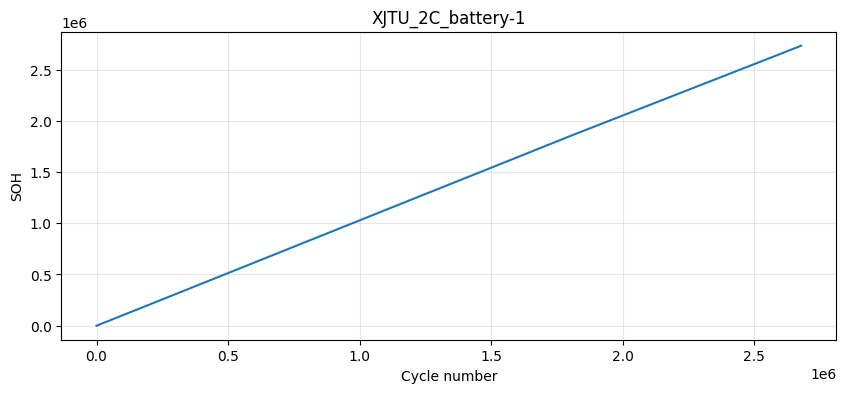

 39%|███▉      | 9/23 [00:20<00:32,  2.32s/it]

XJTU_2C_battery-8.pkl
[0, 1]
2.0 1.893


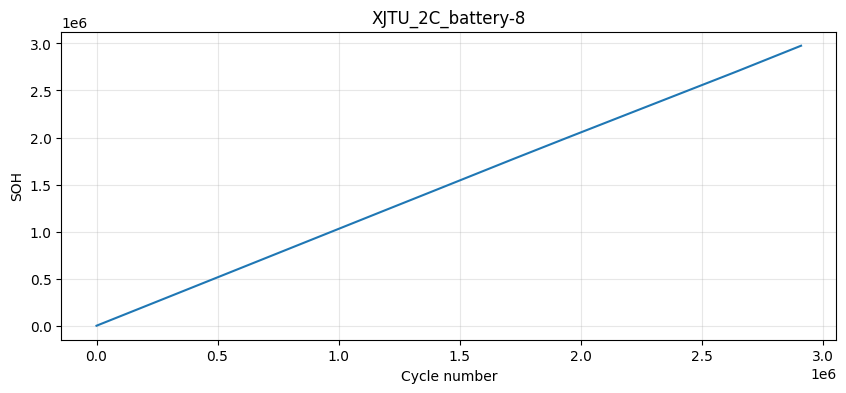

 43%|████▎     | 10/23 [00:23<00:33,  2.55s/it]

XJTU_2C_battery-3.pkl
[0, 1]
2.0 1.861


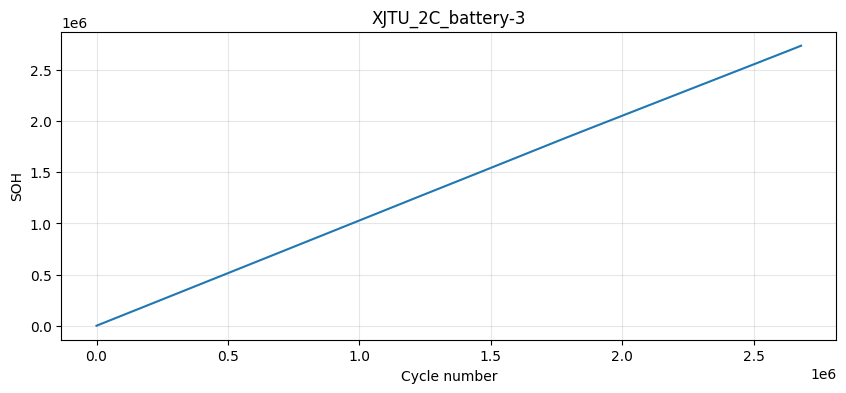

 48%|████▊     | 11/23 [00:26<00:31,  2.60s/it]

XJTU_3C_battery-5.pkl
[0, 1]
2.0 1.87


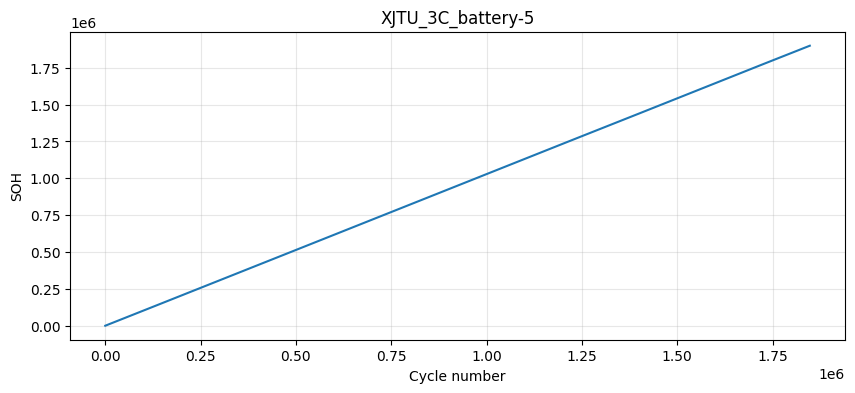

 52%|█████▏    | 12/23 [00:28<00:26,  2.43s/it]

XJTU_3C_battery-13.pkl
[0, 1]
2.0 1.801


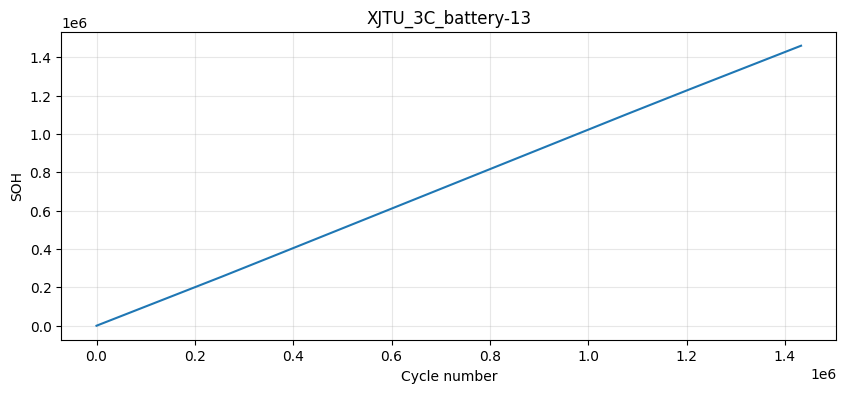

 57%|█████▋    | 13/23 [00:30<00:21,  2.17s/it]

XJTU_3C_battery-10.pkl
[0, 1]
2.0 1.81


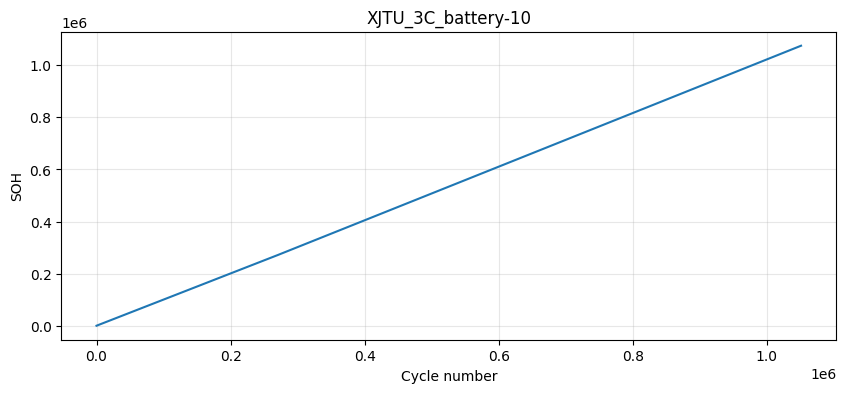

 61%|██████    | 14/23 [00:31<00:16,  1.86s/it]

XJTU_3C_battery-8.pkl
[0, 1]
2.0 1.863


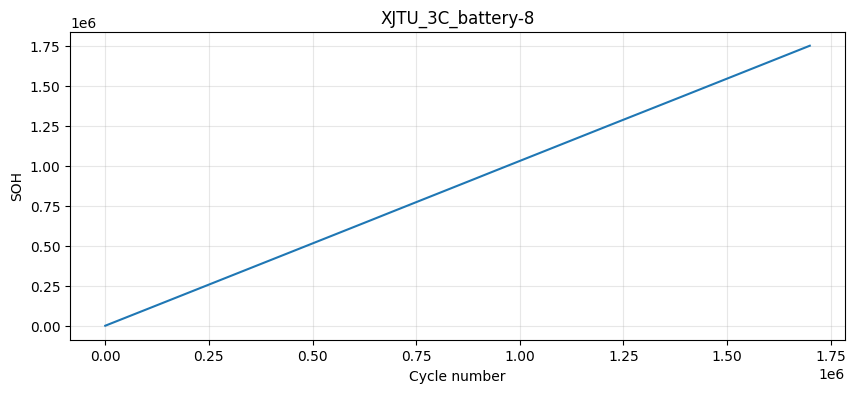

 65%|██████▌   | 15/23 [00:32<00:14,  1.85s/it]

XJTU_3C_battery-12.pkl
[0, 1]
2.0 1.793


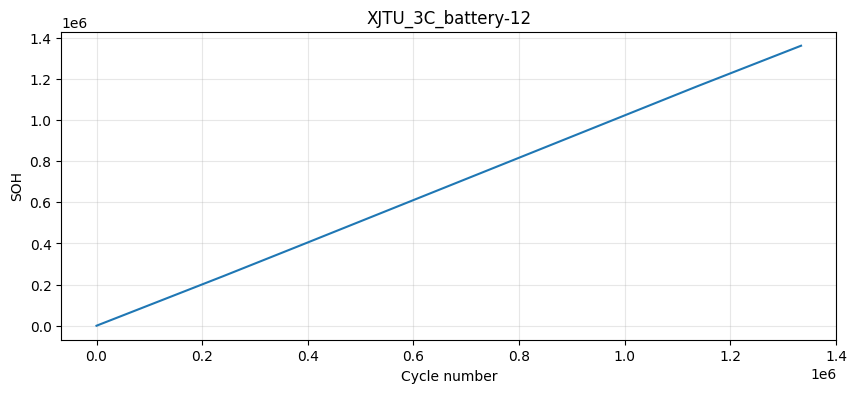

 70%|██████▉   | 16/23 [00:34<00:12,  1.72s/it]

XJTU_3C_battery-2.pkl
[0, 1]
2.0 1.883


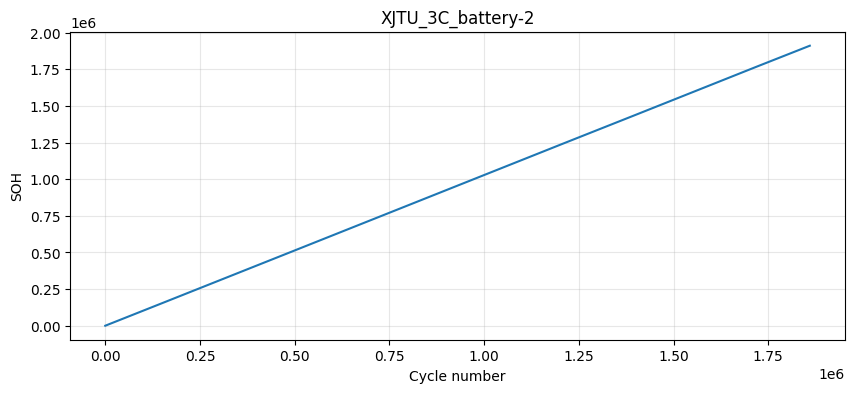

 74%|███████▍  | 17/23 [00:36<00:11,  1.86s/it]

XJTU_3C_battery-4.pkl
[0, 1]
2.0 1.865


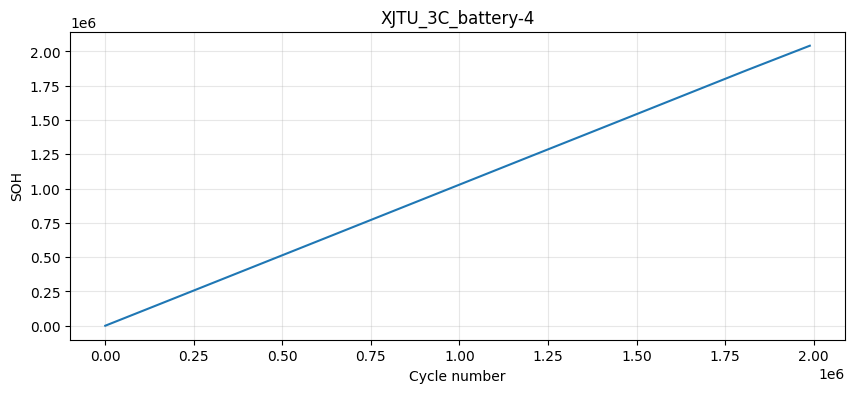

 78%|███████▊  | 18/23 [00:38<00:09,  1.96s/it]

XJTU_2C_battery-6.pkl
[0, 1]
2.0 1.906


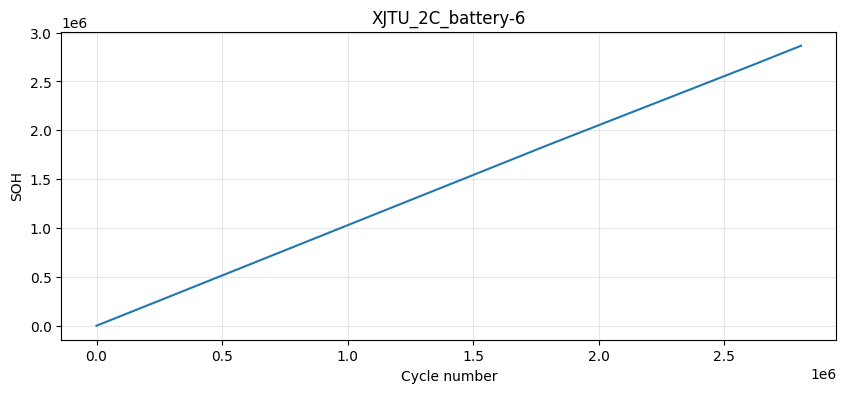

 83%|████████▎ | 19/23 [00:41<00:08,  2.22s/it]

XJTU_3C_battery-1.pkl
[0, 1]
2.0 1.866


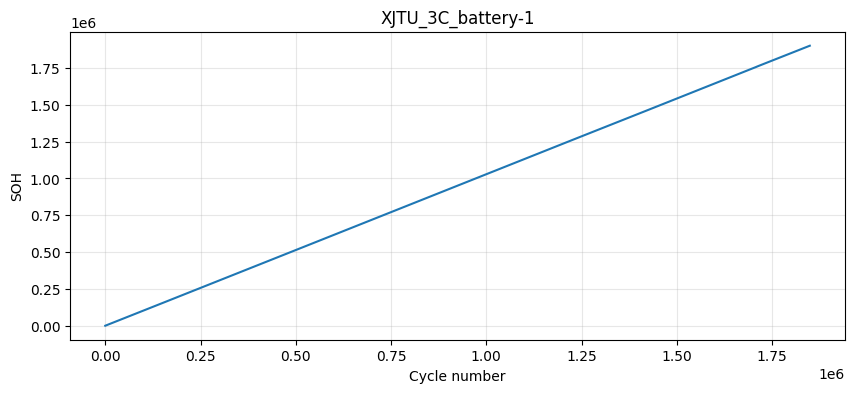

 87%|████████▋ | 20/23 [00:43<00:06,  2.17s/it]

XJTU_3C_battery-15.pkl
[0, 1]
2.0 1.787


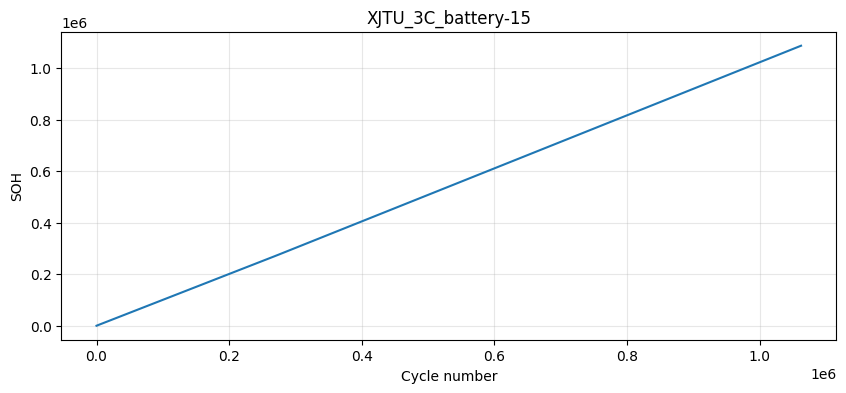

 91%|█████████▏| 21/23 [00:44<00:03,  1.86s/it]

XJTU_2C_battery-5.pkl
[0, 1]
2.0 1.901


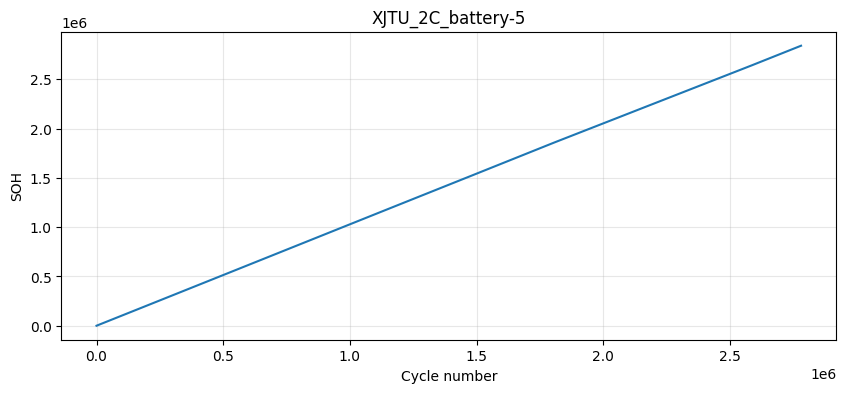

 96%|█████████▌| 22/23 [00:47<00:02,  2.12s/it]

XJTU_3C_battery-11.pkl
[0, 1]
2.0 1.8


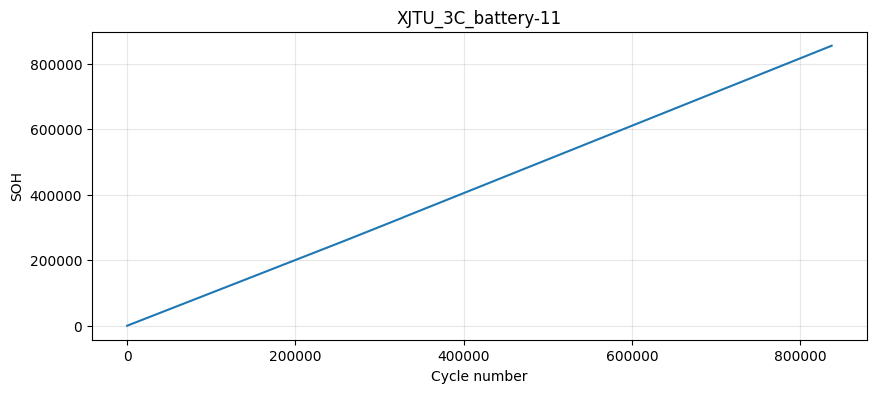

100%|██████████| 23/23 [00:48<00:00,  2.11s/it]


In [2]:
import os
import pickle
import pandas as pd
from openpyxl.styles.builtins import total
from sympy.physics.units import charge
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import json
import seaborn as sns
from scipy.interpolate import PchipInterpolator
from pathlib import Path
from scipy.interpolate import splrep, splev
from scipy import interpolate
import matplotlib.pyplot as plt

from sympy.physics.control.control_plots import matplotlib

path = '/data/trf/python_works/BatteryLife/dataset/XJTU/'
ppath = Path(path)
files = os.listdir(path)
files = [i for i in files if i.endswith('.pkl')]
soc = []
cell = []
life_label = []
file_name = []
total_soh = []
total_cycles = []
data = {}
for file in tqdm(files):
    print(file)
    file_name.append(file)
    with open(path + f'{file}', 'rb') as f:
        cell_data = pickle.load(f)
        filename = file.split('.pkl')[0]
        length = len(cell_data['cycle_data'])
        cell = cell_data['cycle_data']
        nominal_capacity = cell_data['nominal_capacity_in_Ah']


        df = pd.DataFrame()
        SOC_interval = cell_data['SOC_interval']  # get the charge and discharge soc interval
        print(SOC_interval)

        SOC_interval = SOC_interval[1] - SOC_interval[0]


        times = []
        cycles = []
        for i in range(0, length):
            cycle_df = pd.DataFrame()
            cycle_data_len = len(cell_data['cycle_data'][i])
            cycle_data = cell_data['cycle_data'][i]
            cycle_df['current'] = cycle_data['current_in_A']
            cycle_df['voltage'] = cycle_data['voltage_in_V']
            cycle_df['charge_capacity'] = cycle_data['charge_capacity_in_Ah']
            cycle_df['discharge_capacity'] = cycle_data['discharge_capacity_in_Ah']
            cycle_df['test_time_s'] = cycle_data['time_in_s']
            cycle_df['cycle_number'] = cycle_data['cycle_number']
            cycles.append(i+1)

            if file.startswith('CALB_-10'):
                soh_value = abs(cycle_df.loc[cycle_df['current'] < 0, 'discharge_capacity'].min())
            elif 'DefaultGroup' in file:
                soh_value = float(cycle_df['discharge_capacity'].max())
            else:
                soh_value = float(cycle_df.loc[cycle_df['current'] < 0, 'discharge_capacity'].max())


            if SOC_interval == 0:
                SOC_interval = 1

            if i == 0:
                print(nominal_capacity, max(cycle_df['discharge_capacity']))

            times += cycle_df['test_time_s'].tolist()


        fig = plt.figure(figsize=(10, 4))
        plt.xlabel('Cycle number')
        plt.ylabel('SOH')
        plt.grid(alpha=.3)
        plt.plot(range(len(times)), times)
        plt.title(f'{filename}')
        plt.show()

